In [95]:
import pandas as pd
import numpy as np
import pickle
from ctf import CorrelationThresholdFilter

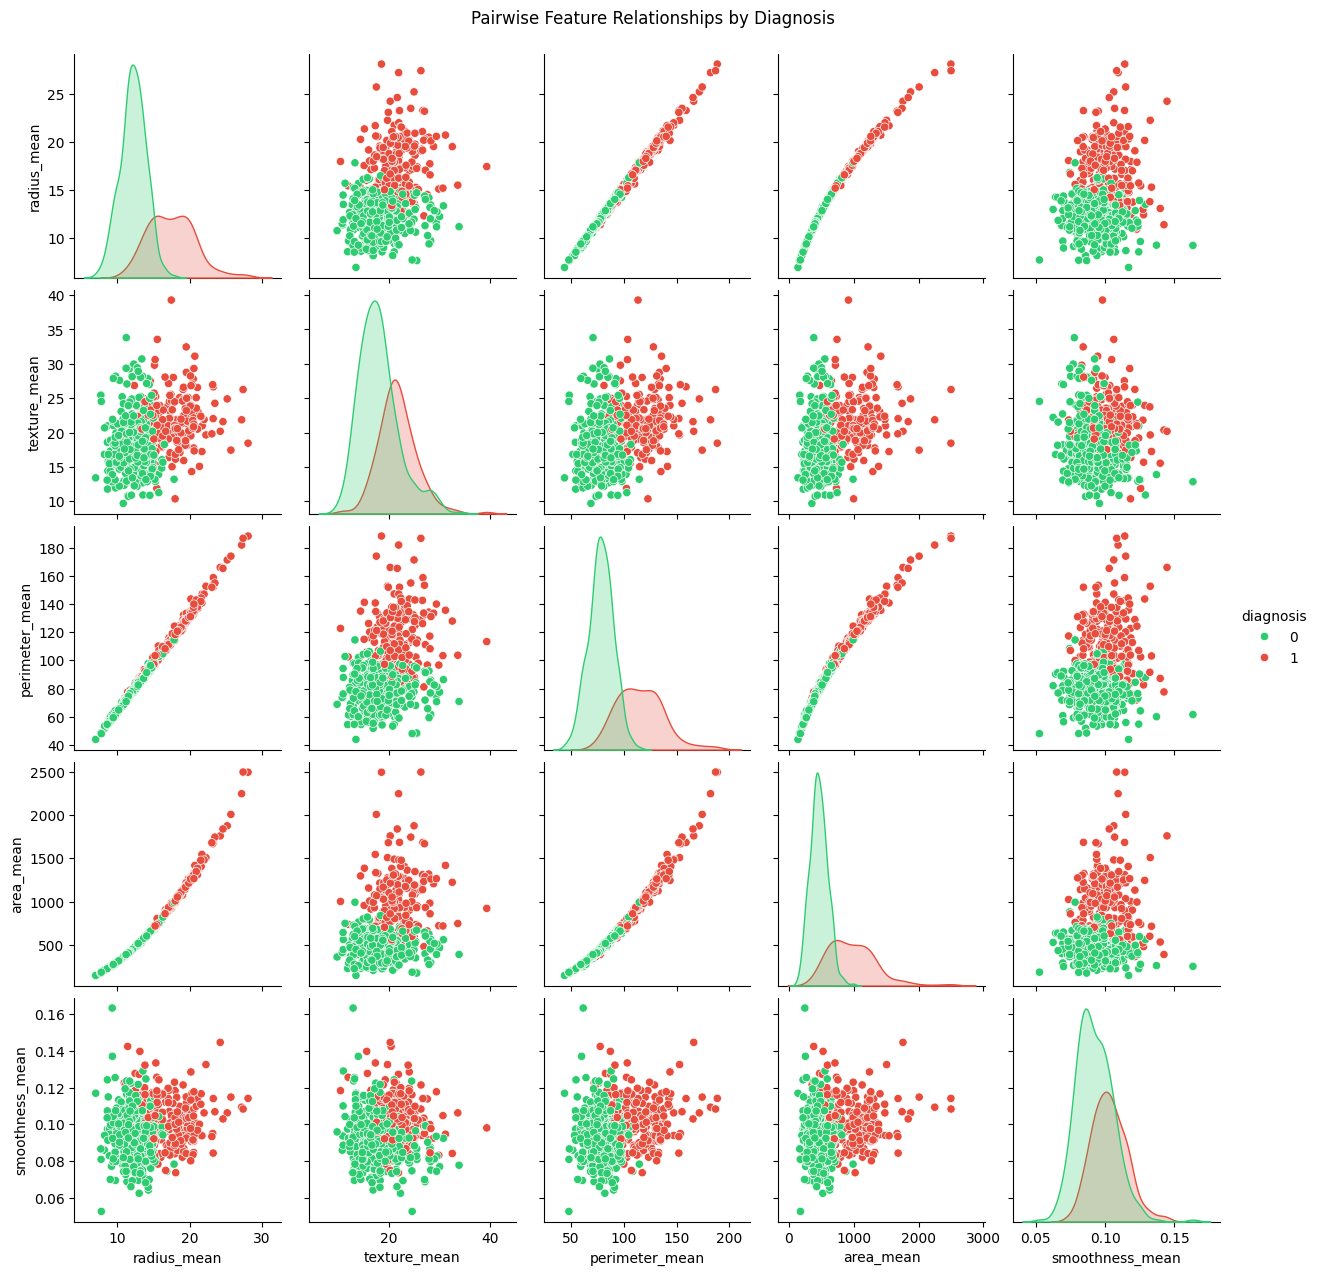

In [96]:
import seaborn as sns
import matplotlib.pyplot as plt

selected_cols = [
    'radius_mean', 
    'texture_mean', 
    'perimeter_mean', 
    'area_mean', 
    'smoothness_mean', 
    'diagnosis'
]

# Pairplot: Scatters off-diagonal, KDE distributions on diagonal
sns.pairplot(
    data=df[selected_cols], 
    hue='diagnosis', 
    palette={0: '#2ecc71', 1: '#e74c3c'},
    diag_kind='kde',
    corner=False  # Set to True to hide the redundant upper triangle
)

plt.suptitle('Pairwise Feature Relationships by Diagnosis', y=1.02)
plt.show()

In [97]:
df = pd.read_csv('data.csv')
# profile = ProfileReport(df, title="Pandas Profiling Report for data.csv", explorative=True)
       
#output_path = 'data_profile_report.html'
# profile.to_file(output_path)

In [98]:
df.sample(15)

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
70,859575,M,18.940,21.31,123.60,1130.0,0.09009,0.10290,0.108000,0.079510,...,26.58,165.90,1866.0,0.11930,0.23360,0.26870,0.17890,0.2551,0.06589,NaN
424,907145,B,9.742,19.12,61.93,289.7,0.10750,0.08333,0.008934,0.019670,...,23.17,71.79,380.9,0.13980,0.13520,0.02085,0.04589,0.3196,0.08009,NaN
311,89382601,B,14.610,15.69,92.68,664.9,0.07618,0.03515,0.014470,0.018770,...,21.75,103.70,840.8,0.10110,0.07087,0.04746,0.05813,0.2530,0.05695,NaN
124,865468,B,13.370,16.39,86.10,553.5,0.07115,0.07325,0.080920,0.028000,...,22.75,91.99,632.1,0.10250,0.25310,0.33080,0.08978,0.2048,0.07628,NaN
380,901549,B,11.270,12.96,73.16,386.3,0.12370,0.11110,0.079000,0.055500,...,20.53,84.93,476.1,0.16100,0.24290,0.22470,0.13180,0.3343,0.09215,NaN
67,859465,B,11.310,19.04,71.80,394.1,0.08139,0.04701,0.037090,0.022300,...,23.84,78.00,466.7,0.12900,0.09148,0.14440,0.06961,0.2400,0.06641,NaN
173,871641,B,11.080,14.71,70.21,372.7,0.10060,0.05743,0.023630,0.025830,...,16.82,72.01,396.5,0.12160,0.08240,0.03938,0.04306,0.1902,0.07313,NaN
135,868202,M,12.770,22.47,81.72,506.3,0.09055,0.05761,0.047110,0.027040,...,33.37,92.04,653.6,0.14190,0.15230,0.21770,0.09331,0.2829,0.08067,NaN
222,8812844,B,10.180,17.53,65.12,313.1,0.10610,0.08502,0.017680,0.019150,...,22.84,71.94,375.6,0.14060,0.14400,0.06572,0.05575,0.3055,0.08797,NaN
38,855133,M,14.990,25.20,95.54,698.8,0.09387,0.05131,0.023980,0.028990,...,25.20,95.54,698.8,0.09387,0.05131,0.02398,0.02899,0.1565,0.05504,NaN


In [99]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [100]:
df.drop(columns=['id', 'Unnamed: 32'], inplace=True)


In [101]:
df.describe()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


In [102]:
df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})

In [103]:
x = df.iloc[:, 1:31]
y = df.iloc[:, 0]

In [104]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error

pipe = Pipeline([
    ('ctf' , CorrelationThresholdFilter(0.1)),
    ('scaler', StandardScaler()), 
    ('pca' , PCA(0.95)),
    ('model' , LogisticRegression()),
])

xtrain, xtest, ytrain, ytest = train_test_split(x, y, test_size=0.2, random_state=42)

pipe.fit(xtrain, ytrain)
print(f"Test Accuracy: {pipe.score(xtest, ytest) * 100:.2f}%")



Test Accuracy: 99.12%


In [105]:
import joblib

joblib.dump(pipe, 'cancer_diagnosis_pipeline.joblib')

['cancer_diagnosis_pipeline.joblib']